# Fire Dataset

In [1]:
# Add project root to path and import config
import sys
import os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

# Explicit imports from config
from config import (
    # Fire dataset paths
    ALGERIA_FIRES_CSV,
    TUNISIA_FIRES_CSV,
    # Landcover shapefile paths
    ALGERIA_SHP,
    TUNISIA_SHP,
    # Results paths
    FIRES_CSV,
    FIRES_RESULT_CSV,
    FIRES_WITH_ARTIFICIAL,
    SEA_CSV,
    # Landcover clean paths
    MERGED_LC_CLEAN,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from datetime import datetime
from scipy import stats
from shapely.ops import unary_union
from shapely.geometry import Point, box

sns.set_theme(style='whitegrid')

# Print config paths for verification
print("Config paths loaded:")
print(f"  FIRES_CSV: {FIRES_CSV}")
print(f"  FIRES_RESULT_CSV: {FIRES_RESULT_CSV}")
print(f"  FIRES_WITH_ARTIFICIAL: {FIRES_WITH_ARTIFICIAL}")

# Load datasets using config paths
try:
    algeria_fires = pd.read_csv(ALGERIA_FIRES_CSV)
    tunisia_fires = pd.read_csv(TUNISIA_FIRES_CSV)
    print('\\nLoaded datasets:')
    print('Algeria:', algeria_fires.shape)
    print('Tunisia:', tunisia_fires.shape)
except Exception as e:
    print('Error loading CSVs:', e)
    algeria_fires = None
    tunisia_fires = None

# Utility: safe column presence
def has_cols(df, cols):
    if df is None:
        return False
    return all(c in df.columns for c in cols)

Config paths loaded:
  FIRES_CSV: C:\Users\Azur\Downloads\TP\DM\results\data\fires.csv
  FIRES_RESULT_CSV: C:\Users\Azur\Downloads\TP\DM\results\data\fires_clipped.csv
  FIRES_WITH_ARTIFICIAL: C:\Users\Azur\Downloads\TP\DM\results\data\fires_with_artificial.csv
\nLoaded datasets:
Algeria: (87446, 15)
Tunisia: (2804, 15)


# 1 - Comprendre les données

Les fonctions ci-dessous inspectent la structure des DataFrames et affichent un aperçu (shape, dtypes, head/tail).

In [2]:
def show_structure(df, name='df'):
    if df is None:
        print(f'{name} is None')
        return
    print(f'=== {name} ===')
    print('\nShape:', df.shape)
    print('\nDtypes:')
    print(df.dtypes)
    print('\nHead:')
    display(df.head())
    print('\nTail:')
    display(df.tail())

# Example usage
show_structure(algeria_fires, 'Algeria fires')
show_structure(tunisia_fires, 'Tunisia fires')

=== Algeria fires ===

Shape: (87446, 15)

Dtypes:
latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version         int64
bright_ti5    float64
frp           float64
daynight       object
type            int64
dtype: object

Head:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,27.72818,9.87200,295.51,0.76,0.77,2024-01-01,3,N20,VIIRS,n,2,277.66,1.24,N,2
1,28.63288,9.77909,301.80,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.05,1.57,N,2
2,28.64012,9.77953,298.65,0.79,0.78,2024-01-01,3,N20,VIIRS,n,2,277.04,1.34,N,2
3,36.74886,6.25409,338.04,0.46,0.39,2024-01-01,141,N20,VIIRS,n,2,257.28,5.21,N,2
4,35.87978,4.44782,309.49,0.41,0.37,2024-01-01,141,N20,VIIRS,n,2,272.08,1.58,N,2



Tail:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
87441,34.86016,-1.37439,337.17,0.43,0.46,2024-12-31,1331,N20,VIIRS,n,2,287.63,3.18,D,0
87442,35.80756,-0.34148,326.23,0.50,0.49,2024-12-31,1331,N20,VIIRS,n,2,282.76,3.58,D,2
87443,36.74493,6.25849,334.95,0.60,0.71,2024-12-31,1331,N20,VIIRS,n,2,286.65,4.28,D,2
87444,36.86816,6.98849,331.50,0.66,0.73,2024-12-31,1331,N20,VIIRS,n,2,285.38,4.55,D,2
87445,36.86970,6.98770,332.72,0.66,0.73,2024-12-31,1332,N20,VIIRS,n,2,284.90,5.24,D,2


=== Tunisia fires ===

Shape: (2804, 15)

Dtypes:
latitude      float64
longitude     float64
bright_ti4    float64
scan          float64
track         float64
acq_date       object
acq_time        int64
satellite      object
instrument     object
confidence     object
version         int64
bright_ti5    float64
frp           float64
daynight       object
type            int64
dtype: object

Head:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,31.64847,9.16945,315.79,0.53,0.50,2024-01-01,142,N20,VIIRS,n,2,279.09,2.20,N,2
1,31.49290,9.48947,302.32,0.56,0.51,2024-01-01,142,N20,VIIRS,n,2,276.10,1.23,N,0
2,31.49524,9.49053,301.88,0.56,0.51,2024-01-01,142,N20,VIIRS,n,2,276.12,0.77,N,0
3,33.36728,8.54768,302.58,0.45,0.47,2024-01-01,142,N20,VIIRS,n,2,277.15,0.80,N,2
4,31.64812,9.17107,320.80,0.46,0.39,2024-01-02,124,N20,VIIRS,n,2,278.37,2.44,N,2



Tail:


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
2799,31.65023,9.17049,308.73,0.50,0.41,2024-12-30,50,N20,VIIRS,n,2,278.50,1.21,N,2
2800,31.64881,9.17031,323.63,0.61,0.53,2024-12-31,31,N20,VIIRS,n,2,279.46,2.57,N,2
2801,31.65072,9.16963,320.75,0.61,0.53,2024-12-31,31,N20,VIIRS,n,2,279.13,3.50,N,2
2802,36.59308,10.31617,296.55,0.63,0.72,2024-12-31,210,N20,VIIRS,n,2,278.94,1.12,N,2
2803,31.64872,9.17024,309.77,0.74,0.76,2024-12-31,212,N20,VIIRS,n,2,278.10,2.16,N,2


# 2 - Statistiques descriptives

Fonctions pour calculer les statistiques de base (moyenne, médiane, std, variance, mode, describe).

In [3]:
def descriptive_stats(df, numeric_only=True):
    if df is None:
        return None
    if numeric_only:
        return df.describe()
    else:
        return df.describe(include='all')

print('Descriptive stats - Algeria :\n')
print(descriptive_stats(algeria_fires))
print('\nDescriptive stats - Tunisia :\n')
print(descriptive_stats(tunisia_fires))

Descriptive stats - Algeria :

           latitude     longitude    bright_ti4          scan         track  \
count  87446.000000  87446.000000  87446.000000  87446.000000  87446.000000   
mean      31.398370      6.174013    321.170189      0.476433      0.516127   
std        2.642515      2.563073     18.189028      0.101948      0.126665   
min       19.603230     -8.118050    240.170000      0.320000      0.360000   
25%       28.735780      5.585470    305.500000      0.400000      0.400000   
50%       31.403925      6.475440    316.820000      0.450000      0.500000   
75%       32.515890      7.906365    337.420000      0.540000      0.620000   
max       37.022990     10.993650    367.000000      0.800000      0.780000   

           acq_time  version    bright_ti5           frp          type  
count  87446.000000  87446.0  87446.000000  87446.000000  87446.000000  
mean     379.367941      2.0    291.711062      3.454114      1.703863  
std      479.842612      0.0     11.71

# 3 - Analyse univariée

Histogrammes, boxplots et density plots pour chaque variable numérique.
(Exclut automatiquement les colonnes non-numériques et les colonnes inutiles.)

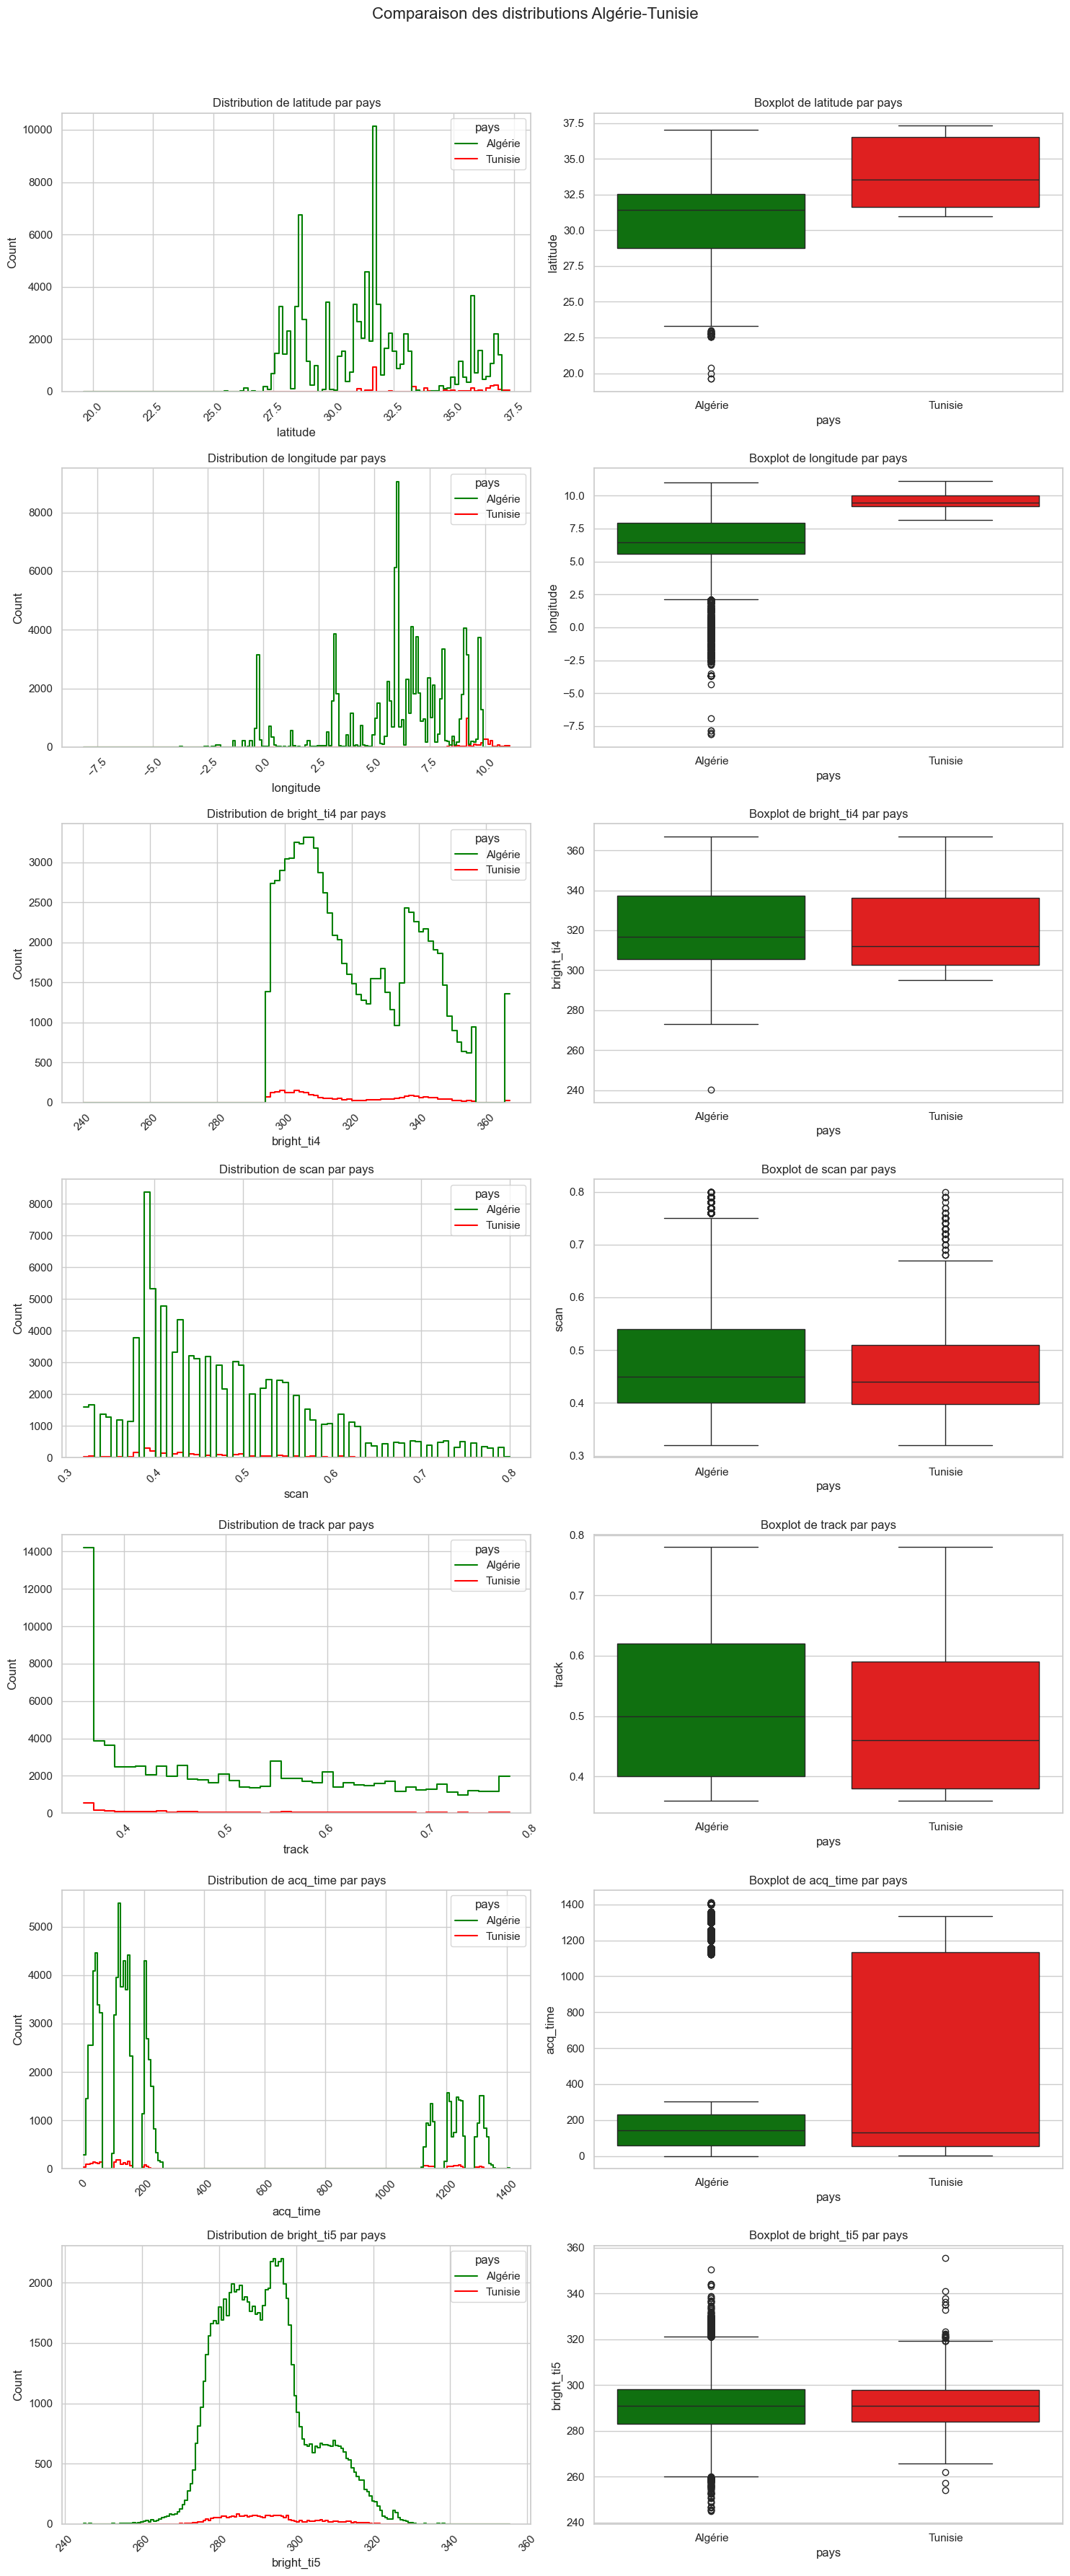

In [4]:
# Préparation des données pour la comparaison
# Ajout d'une colonne 'pays' pour identifier l'origine des données
algeria_fires['pays'] = 'Algérie'
tunisia_fires['pays'] = 'Tunisie'

# Combiner les deux datasets
combined_fires = pd.concat([algeria_fires, tunisia_fires])

# Fonction pour créer des visualisations comparatives
def plot_comparative_distributions(df, numeric_columns):
    # Exclure les colonnes spécifiées
    columns_to_exclude = ['version', 'frp', 'type']
    numeric_columns = [col for col in numeric_columns if col not in columns_to_exclude]
    n_cols = len(numeric_columns)
    
    # Définir les couleurs
    colors = {'Algérie': 'green', 'Tunisie': 'red'}
    
    # Création des subplots
    fig, axes = plt.subplots(n_cols, 2, figsize=(15, 5*n_cols))
    fig.suptitle('Comparaison des distributions Algérie-Tunisie', y=1.02, fontsize=16)
    
    # Si une seule colonne, convertir axes en tableau 2D
    if n_cols == 1:
        axes = np.array([axes])
    
    for i, col in enumerate(numeric_columns):
        # Histogramme sans KDE pour éviter les erreurs
        sns.histplot(data=df, x=col, hue='pays', ax=axes[i,0], 
                    element="step", fill=False,
                    palette=colors)
        axes[i,0].set_title(f'Distribution de {col} par pays')
        axes[i,0].tick_params(axis='x', rotation=45)
        
        # Boxplot avec hue au lieu de palette
        sns.boxplot(data=df, y=col, hue='pays', x='pays', ax=axes[i,1],
                   palette=colors, legend=False)
        axes[i,1].set_title(f'Boxplot de {col} par pays')
    
    plt.tight_layout()
    plt.show()

# Sélection des colonnes numériques communes
numeric_cols = combined_fires.select_dtypes(include=['float64', 'int64']).columns
plot_comparative_distributions(combined_fires, numeric_cols)

# 4 - Analyse bivariée

Correlation matrix, scatterplots and heatmaps between numeric variables.

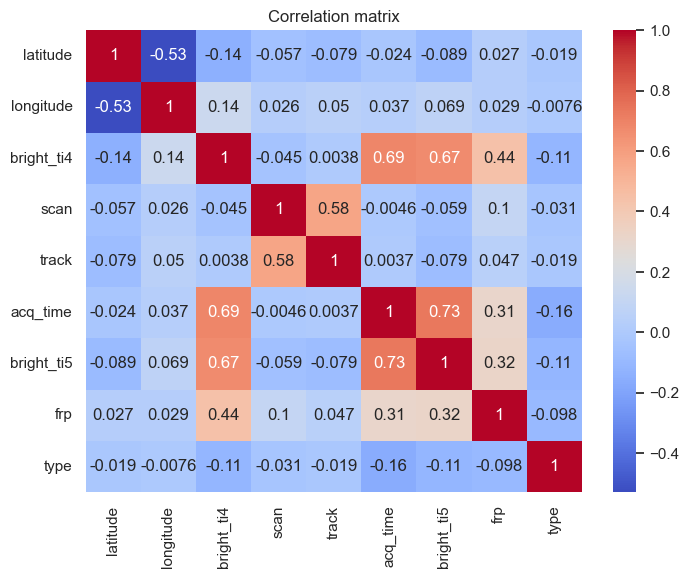

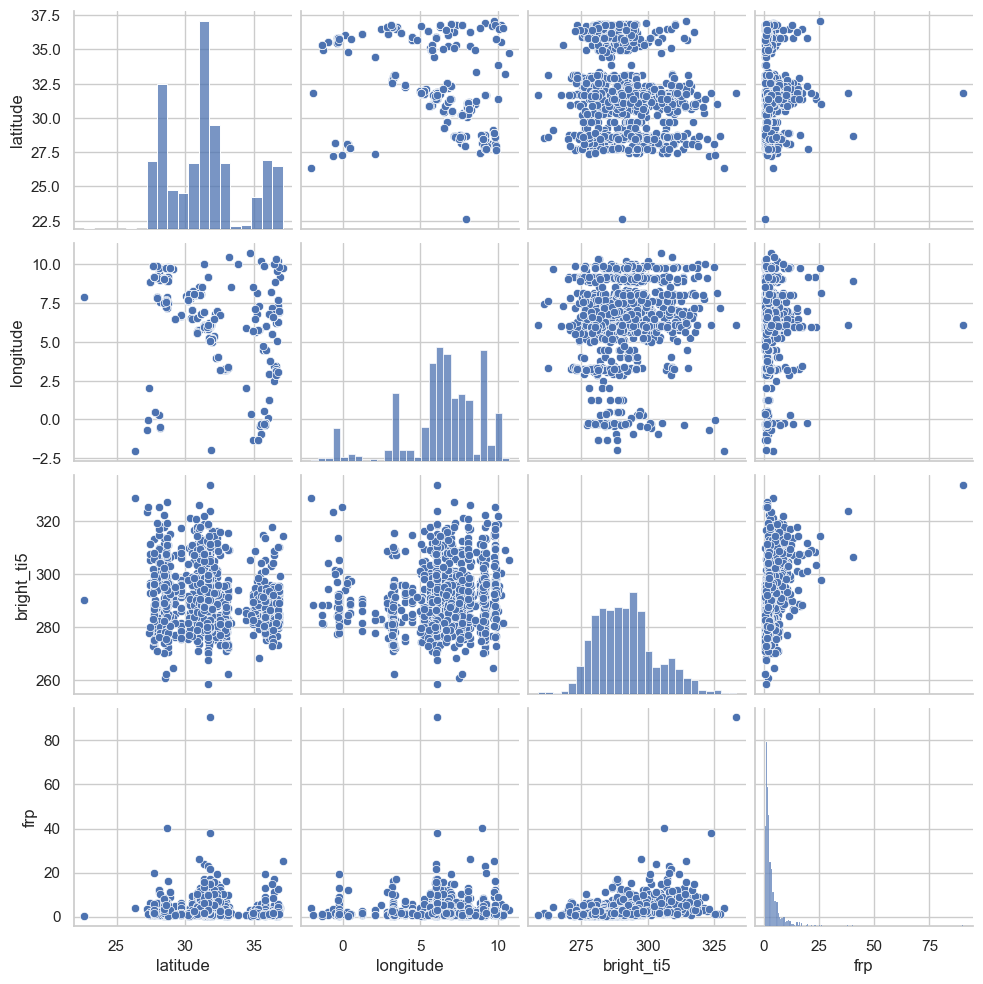

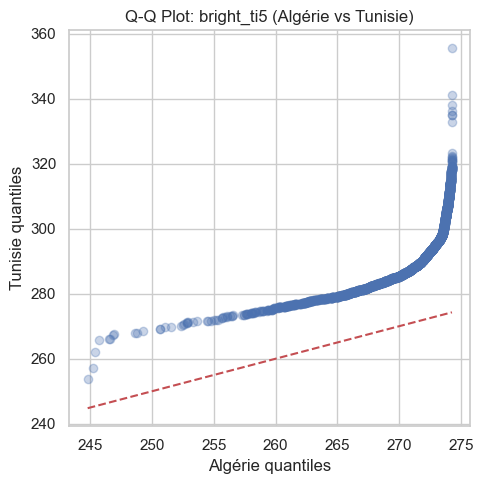

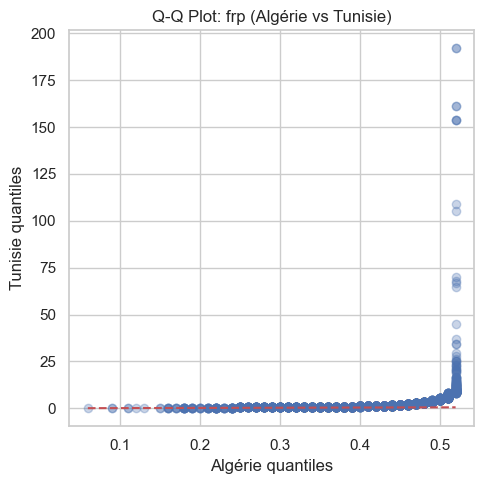

In [5]:
def qq_compare(df, country_col='pays', features=['bright_ti5', 'frp']):
    countries = df[country_col].unique()
    if len(countries) < 2:
        print("Need at least two countries for Q-Q comparison.")
        return
    c1, c2 = countries[:2]
    for feat in features:
        if feat not in df.columns:
            continue
        data1 = df[df[country_col] == c1][feat].dropna()
        data2 = df[df[country_col] == c2][feat].dropna()
        min_len = min(len(data1), len(data2))
        if min_len == 0:
            continue
        # Sort and align quantiles
        q1 = np.sort(data1)[:min_len]
        q2 = np.sort(data2)[:min_len]
        plt.figure(figsize=(5,5))
        plt.scatter(q1, q2, alpha=0.3)
        plt.plot([q1.min(), q1.max()], [q1.min(), q1.max()], 'r--')
        plt.xlabel(f'{c1} quantiles')
        plt.ylabel(f'{c2} quantiles')
        plt.title(f'Q-Q Plot: {feat} ({c1} vs {c2})')
        plt.tight_layout()
        plt.show()


def plot_bivariate(df, exclude_cols=None):
    if df is None:
        return
    if exclude_cols is None:
        exclude_cols = []
    numeric = df.select_dtypes(include=['number']).columns
    numeric = [c for c in numeric if c not in exclude_cols]
    if len(numeric) < 2:
        print('Not enough numeric columns for bivariate plots')
        return
    
    # Correlation matrix
    corr = df[numeric].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation matrix')
    plt.show()
    # Select only relevant features for pairwise scatter
    relevant_features = ['latitude', 'longitude', 'bright_ti5', 'frp']

    # Pairwise scatter (sample if large)
    sample = df[relevant_features].dropna()
    if sample.shape[0] > 1000:
        sample = sample.sample(1000, random_state=0)
    sns.pairplot(sample)
    plt.show()

    # Q-Q plots
    qq_compare(combined_fires, features=['bright_ti5', 'frp'])

    
plot_bivariate(pd.concat([algeria_fires,tunisia_fires], ignore_index=True), exclude_cols=["version"])

# Distribution of the fire types

Original Data:


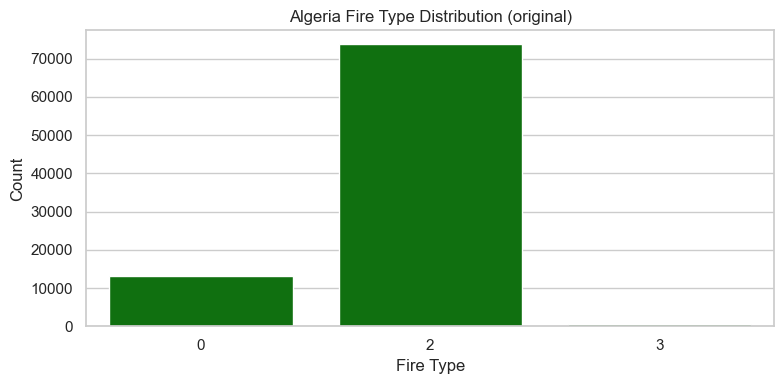


Algeria fire type counts:
type
0    13216
2    73694
3      536
Name: count, dtype: int64


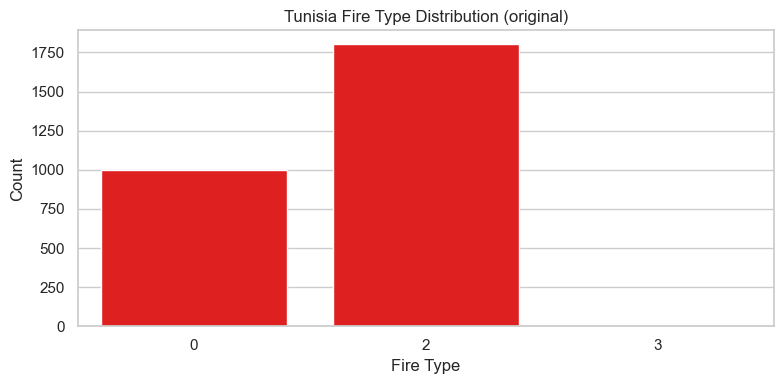


Tunisia fire type counts:
type
0    1000
2    1801
3       3
Name: count, dtype: int64


In [6]:
def plot_fire_type_distribution(df, country_name, color, title_suffix=''):
    if df is None or 'type' not in df.columns:
        print(f'No type column in {country_name} dataset')
        return
    type_counts = df['type'].value_counts().sort_index()
    plt.figure(figsize=(8,4))
    sns.barplot(x=type_counts.index, y=type_counts.values, color=color)
    plt.title(f'{country_name} Fire Type Distribution {title_suffix}')
    plt.xlabel('Fire Type')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    # Print actual counts
    print(f"\n{country_name} fire type counts:")
    print(type_counts)

# 1) Original datasets (separate plots)
print("Original Data:")
plot_fire_type_distribution(algeria_fires, 'Algeria', 'green', '(original)')
plot_fire_type_distribution(tunisia_fires, 'Tunisia', 'red', '(original)')

# 5 - Analyse Temporelle

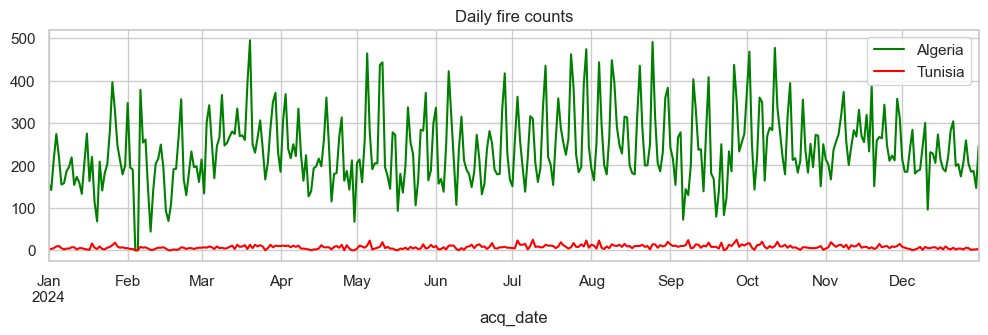

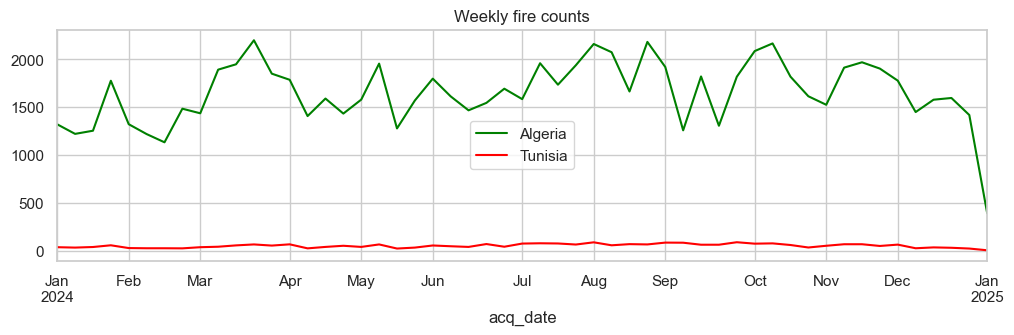

In [7]:
def temporal_analysis_dual(df1, df2, label1='Algeria', label2='Tunisia', date_col_candidates=['acq_date','acq_datetime','date','time']):
    # Find date column for each
    def get_date_col(df):
        for c in date_col_candidates:
            if c in df.columns:
                return c
        return None
    col1 = get_date_col(df1)
    col2 = get_date_col(df2)
    if col1 is None or col2 is None:
        print('No date column found in one of the datasets')
        return
    d1 = df1.copy()
    d2 = df2.copy()
    d1[col1] = pd.to_datetime(d1[col1], errors='coerce')
    d2[col2] = pd.to_datetime(d2[col2], errors='coerce')
    d1 = d1.dropna(subset=[col1]).set_index(col1)
    d2 = d2.dropna(subset=[col2]).set_index(col2)
    # Daily counts
    c1 = d1.resample('D').size()
    c2 = d2.resample('D').size()
    plt.figure(figsize=(12,3))
    c1.plot(label=label1, color='green')
    c2.plot(label=label2, color='red')
    plt.title('Daily fire counts')
    plt.legend()
    plt.show()
    # Weekly counts
    w1 = d1.resample('W').size()
    w2 = d2.resample('W').size()
    plt.figure(figsize=(12,3))
    w1.plot(label=label1, color='green')
    w2.plot(label=label2, color='red')
    plt.title('Weekly fire counts')
    plt.legend()
    plt.show()

# Example
# temporal_analysis_dual(algeria_clean, tunisia_clean)
temporal_analysis_dual(algeria_fires, tunisia_fires, label1='Algeria', label2='Tunisia')


# 6 - Analyse Spatiale

PLOT 1: RAW FIRE DATA (ALL TYPES)
[LOAD] Loading Algeria landcover shapefile...
[LOAD] Loading Tunisia landcover shapefile...

[STEP 1] Saving raw concatenated data...
  Saved raw data to: C:\Users\Azur\Downloads\TP\DM\results\data\fires.csv
  Total rows: 90,250

[STEP 2] Loading data from FIRES_CSV for visualization...
Raw data (all fire types) from fires.csv:
  Algeria: 74,016 points
  Tunisia: 16,234 points
  Total: 90,250 points


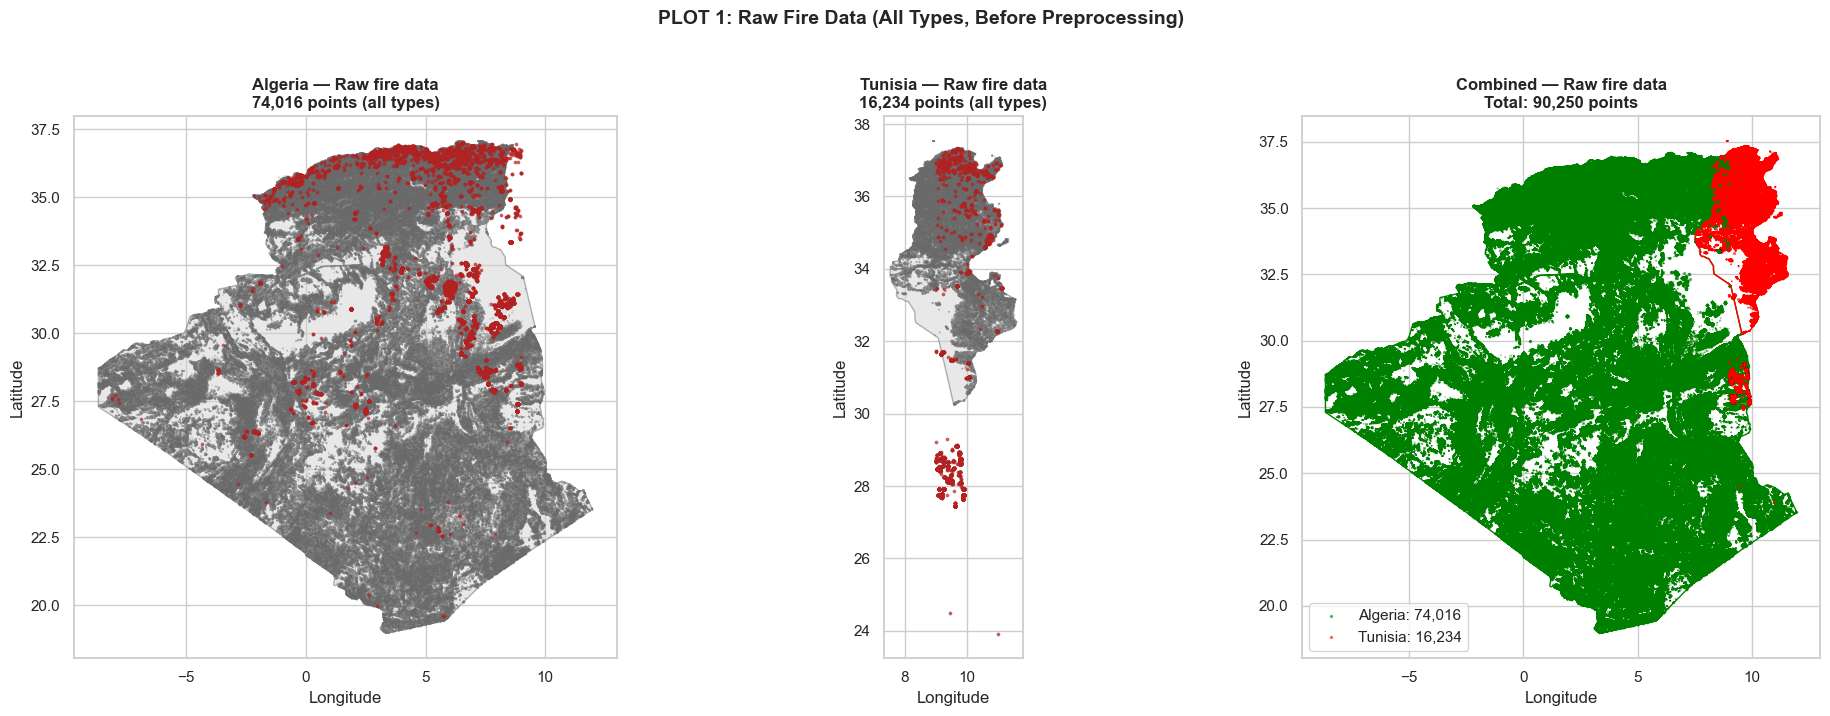


Fire type distribution:
  {0: 14216, 2: 75495, 3: 539}

✓ Raw data saved to: C:\Users\Azur\Downloads\TP\DM\results\data\fires.csv


In [8]:
# ============================================================================
# PLOT 1: RAW DATA (All fire types, before preprocessing)
# ============================================================================
print("="*80)
print("PLOT 1: RAW FIRE DATA (ALL TYPES)")
print("="*80)

# Load landcover data for boundaries (cache if not already loaded)
if 'algeria_lc' not in dir() or algeria_lc is None:
    print("[LOAD] Loading Algeria landcover shapefile...")
    algeria_lc = gpd.read_file(ALGERIA_SHP)
else:
    print("[CACHE] Using cached Algeria landcover data")

if 'tunisia_lc' not in dir() or tunisia_lc is None:
    print("[LOAD] Loading Tunisia landcover shapefile...")
    tunisia_lc = gpd.read_file(TUNISIA_SHP)
else:
    print("[CACHE] Using cached Tunisia landcover data")

# ============================================================================
# STEP 1: Save raw concatenated data to FIRES_CSV
# ============================================================================
print("\n[STEP 1] Saving raw concatenated data...")
raw_combined = pd.concat([algeria_fires, tunisia_fires], ignore_index=True)
raw_combined.to_csv(FIRES_CSV, index=False)
print(f"  Saved raw data to: {FIRES_CSV}")
print(f"  Total rows: {len(raw_combined):,}")

# ============================================================================
# STEP 2: Load from FIRES_CSV for plotting
# ============================================================================
print("\n[STEP 2] Loading data from FIRES_CSV for visualization...")
raw_df = pd.read_csv(FIRES_CSV)

# Separate by country (using longitude as proxy: Algeria < 9, Tunisia >= 9)
algeria_raw = raw_df[raw_df['longitude'] < 9].copy()
tunisia_raw = raw_df[raw_df['longitude'] >= 9].copy()

print(f"Raw data (all fire types) from {FIRES_CSV.name}:")
print(f"  Algeria: {len(algeria_raw):,} points")
print(f"  Tunisia: {len(tunisia_raw):,} points")
print(f"  Total: {len(raw_df):,} points")

# Create geodataframes
def create_fire_gdf(df):
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
        crs='EPSG:4326'
    )

alg_gdf = create_fire_gdf(algeria_raw)
tn_gdf = create_fire_gdf(tunisia_raw)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Left: Algeria
ax1 = axes[0]
algeria_lc.plot(ax=ax1, edgecolor='dimgray', facecolor='lightgray', alpha=0.5)
alg_gdf.plot(ax=ax1, markersize=3, color='firebrick', alpha=0.6)
ax1.set_title(f'Algeria — Raw fire data\n{len(algeria_raw):,} points (all types)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Middle: Tunisia
ax2 = axes[1]
tunisia_lc.plot(ax=ax2, edgecolor='dimgray', facecolor='lightgray', alpha=0.5)
tn_gdf.plot(ax=ax2, markersize=3, color='firebrick', alpha=0.6)
ax2.set_title(f'Tunisia — Raw fire data\n{len(tunisia_raw):,} points (all types)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

# Right: Combined view
ax3 = axes[2]
algeria_lc.plot(ax=ax3, edgecolor='green', facecolor='none', linewidth=1)
tunisia_lc.plot(ax=ax3, edgecolor='red', facecolor='none', linewidth=1)
alg_gdf.plot(ax=ax3, markersize=2, color='green', alpha=0.5, label=f'Algeria: {len(algeria_raw):,}')
tn_gdf.plot(ax=ax3, markersize=2, color='red', alpha=0.5, label=f'Tunisia: {len(tunisia_raw):,}')
ax3.set_title(f'Combined — Raw fire data\nTotal: {len(raw_df):,} points', fontsize=12, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.legend(loc='lower left')

plt.suptitle('PLOT 1: Raw Fire Data (All Types, Before Preprocessing)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFire type distribution:")
print(f"  {raw_df['type'].value_counts().sort_index().to_dict()}")
print(f"\n✓ Raw data saved to: {FIRES_CSV}")

# 7 - Data Preprocessing

Includes cleaning (missing values, duplicates, outliers) and clipping utilities.

In [9]:
print("="*80)
print("DATA PREPROCESSING PIPELINE")
print("="*80)

# ============================================================================
# CHECK IF PREPROCESSING CAN BE SKIPPED
# ============================================================================
FORCE_REPROCESS = False  # Set to True to force reprocessing even if file exists

_skip_preprocessing = False
if not FORCE_REPROCESS and os.path.exists(FIRES_RESULT_CSV):
    try:
        _existing_result = pd.read_csv(FIRES_RESULT_CSV)
        _required_cols = {'longitude', 'latitude', 'class'}
        if _required_cols.issubset(set(_existing_result.columns)) and len(_existing_result) > 0 and (_existing_result['class'] == 1).all():
            print(f"✓ [SKIP] Preprocessed data already exists")
            print(f"  File: {FIRES_RESULT_CSV}")
            print(f"  Rows: {len(_existing_result):,}, Columns: {list(_existing_result.columns)}")
            combined_fires_final = _existing_result
            algeria_clean = _existing_result[_existing_result['longitude'] < 9].copy()
            tunisia_clean = _existing_result[_existing_result['longitude'] >= 9].copy()
            print(f"  Algeria: {len(algeria_clean):,} | Tunisia: {len(tunisia_clean):,}")
            print("  Set FORCE_REPROCESS=True to reprocess")
            _skip_preprocessing = True
            del _existing_result
    except Exception as e:
        print(f"[INFO] Could not load existing file: {e}. Running preprocessing...")

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def exclude_type_2_fires(df, verbose=True):
    """Keep only type 0 fires from dataset."""
    if df is None or 'type' not in df.columns:
        return df
    
    if verbose:
        print(f"Before: {len(df)} rows")
        print(f"Fire types distribution before filtering:")
        print(df['type'].value_counts().sort_index())
    
    df_clean = df[df['type'] == 0].copy()
    
    if verbose:
        print(f"After: {len(df_clean)} rows")
        print(f"Removed: {len(df) - len(df_clean)} rows with type != 0")
    
    return df_clean


def drop_duplicates_from_df(df, verbose=True):
    """Remove duplicate rows."""
    if df is None:
        return df
    
    if verbose:
        duplicates_count = df.duplicated().sum()
        print(f"Before: {len(df)} rows")
    df_clean = df.drop_duplicates()
    if verbose:
        print(f"After: {len(df_clean)} rows")
        print(f"Removed: {duplicates_count} duplicate rows")
    return df_clean


def fill_missing_values(df, verbose=True):
    """Fill missing values based on column type."""
    if df is None:
        return df
    
    df_clean = df.copy()
    
    # Check initial missing values
    if verbose:
        missing_before = df_clean.isnull().sum()
        if missing_before.sum() > 0:
            print("\nMissing values per column BEFORE filling:")
            print(missing_before[missing_before > 0])
    
    # Identify column types
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    date_cols = []
    categorical_cols = []
    
    for col in df_clean.columns:
        if col in numeric_cols:
            continue
        if 'date' in col.lower() or 'time' in col.lower():
            date_cols.append(col)
        else:
            categorical_cols.append(col)
    
    if verbose:
        print(f"\nColumn types identified:")
        print(f"  Numeric: {numeric_cols}")
        print(f"  Date: {date_cols}")
        print(f"  Categorical: {categorical_cols}")
    
    # Fill numeric columns with MEDIAN
    if numeric_cols:
        if verbose:
            print("\nFilling numeric columns with MEDIAN...")
        for col in numeric_cols:
            if df_clean[col].isnull().sum() > 0:
                median_val = df_clean[col].median()
                df_clean[col].fillna(median_val, inplace=True)
                if verbose:
                    print(f"  {col}: filled with {median_val}")
    
    # Fill date columns with INTERPOLATION
    if date_cols:
        if verbose:
            print("\nFilling date columns with INTERPOLATION...")
        for col in date_cols:
            if df_clean[col].isnull().sum() > 0:
                df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
                df_clean[col] = pd.to_datetime(
                    df_clean[col].astype(np.int64).interpolate(method='linear').astype(np.int64),
                    errors='coerce'
                )
                df_clean[col].ffill(inplace=True)
                df_clean[col].bfill(inplace=True)
                if verbose:
                    print(f"  {col}: interpolated")
    
    # Fill categorical columns with MODE
    if categorical_cols:
        if verbose:
            print("\nFilling categorical columns with MODE...")
        for col in categorical_cols:
            if df_clean[col].isnull().sum() > 0:
                mode_val = df_clean[col].mode()
                if len(mode_val) > 0:
                    df_clean[col].fillna(mode_val[0], inplace=True)
                    if verbose:
                        print(f"  {col}: filled with '{mode_val[0]}'")
    
    return df_clean


def add_class_column(df, class_value=1, verbose=True):
    """Add class column with specified value."""
    if df is None:
        return df
    
    df_clean = df.copy()
    df_clean['class'] = class_value
    if verbose:
        print(f"Column 'class' added with value {class_value}. Shape: {df_clean.shape}")
    return df_clean


def filter_by_latitude(df, min_latitude=33, verbose=True):
    """Remove rows with latitude below threshold."""
    if df is None or 'latitude' not in df.columns:
        return df
    
    if verbose:
        print(f"Before: {len(df)} rows")
        print(f"Latitude range before: [{df['latitude'].min():.2f}, {df['latitude'].max():.2f}]")
    
    rows_below = (df['latitude'] < min_latitude).sum()
    df_clean = df[df['latitude'] >= min_latitude].copy()
    
    if verbose:
        print(f"After: {len(df_clean)} rows")
        print(f"Removed: {rows_below} rows with latitude < {min_latitude}")
        print(f"Latitude range after: [{df_clean['latitude'].min():.2f}, {df_clean['latitude'].max():.2f}]")
    
    return df_clean


def replace_outliers(df, exclude_cols=['latitude', 'longitude', 'class'], verbose=True):
    """Replace outliers using IQR method."""
    if df is None:
        return df
    
    df_clean = df.copy()
    
    # Get numeric columns (excluding specified columns)
    numeric_cols = [col for col in df_clean.select_dtypes(include=[np.number]).columns 
                    if col not in exclude_cols]
    
    if verbose and numeric_cols:
        print(f"\nAnalyzing outliers in: {numeric_cols}")
    
    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        outliers_count = outliers_mask.sum()
        
        if outliers_count > 0:
            median_val = df_clean[col].median()
            df_clean.loc[outliers_mask, col] = median_val
            if verbose:
                print(f"  {col}: Replaced {outliers_count} outliers ({100*outliers_count/len(df_clean):.2f}%) with median {median_val:.2f}")
    
    # Handle categorical columns
    categorical_cols = [col for col in df_clean.select_dtypes(include=['object']).columns]
    if categorical_cols and verbose:
        print(f"\nCategorical columns (using mode for rare values): {categorical_cols}")
    
    for col in categorical_cols:
        value_counts = df_clean[col].value_counts()
        rare_threshold = len(df_clean) * 0.01
        rare_values = value_counts[value_counts < rare_threshold].index
        
        if len(rare_values) > 0:
            mode_val = df_clean[col].mode()[0]
            rare_mask = df_clean[col].isin(rare_values)
            df_clean.loc[rare_mask, col] = mode_val
            if verbose:
                print(f"  {col}: Replaced {rare_mask.sum()} rare values with mode '{mode_val}'")
    
    return df_clean


def keep_columns(df, columns_to_keep, verbose=True):
    """Keep only specified columns."""
    if df is None:
        return df
    
    if verbose:
        print(f"Before: {df.shape[1]} columns")
    
    available_cols = [col for col in columns_to_keep if col in df.columns]
    df_clean = df[available_cols].copy()
    
    if verbose:
        print(f"After: {df_clean.shape[1]} columns")
        print(f"Columns kept: {available_cols}")
    
    return df_clean


def preprocess_dataset(df, name='Dataset', min_latitude=33, keep_cols=['longitude', 'latitude', 'class'], verbose=True):
    """
    Complete preprocessing pipeline for a single dataset.
    Returns cleaned dataframe.
    """
    if df is None:
        return None
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"PREPROCESSING: {name}")
        print(f"{'='*60}")
        print(f"Initial shape: {df.shape}")
    
    # Apply preprocessing steps
    df_clean = exclude_type_2_fires(df, verbose=verbose)
    df_clean = drop_duplicates_from_df(df_clean, verbose=verbose)
    df_clean = fill_missing_values(df_clean, verbose=verbose)
    df_clean = add_class_column(df_clean, class_value=1, verbose=verbose)
    df_clean = filter_by_latitude(df_clean, min_latitude=min_latitude, verbose=verbose)
    df_clean = replace_outliers(df_clean, verbose=verbose)
    df_clean = keep_columns(df_clean, columns_to_keep=keep_cols, verbose=verbose)
    
    if verbose:
        print(f"\nFinal shape: {df_clean.shape}")
        print(f"{'='*60}\n")
    
    return df_clean


# ============================================================================
# MAIN PREPROCESSING (only if not skipped)
# ============================================================================
if not _skip_preprocessing:
    # Set latitude threshold
    latitude_bound = 33

    print("\\n" + "="*80)
    print("PREPROCESSING INDIVIDUAL DATASETS")
    print("="*80)

    # Preprocess Algeria dataset
    algeria_clean = preprocess_dataset(
        algeria_fires, 
        name='Algeria',
        min_latitude=latitude_bound,
        keep_cols=['longitude', 'latitude', 'class'],
        verbose=True
    )

    # Preprocess Tunisia dataset
    tunisia_clean = preprocess_dataset(
        tunisia_fires,
        name='Tunisia',
        min_latitude=latitude_bound,
        keep_cols=['longitude', 'latitude', 'class'],
        verbose=True
    )

    print("\\n" + "="*80)
    print("PREPROCESSING COMBINED DATASET")
    print("="*80)

    # ============================================================================
    # STEP 1: Concatenate Algeria and Tunisia datasets
    # ============================================================================
    print("\\n[STEP 1] Concatenating Algeria and Tunisia datasets...")
    combined_fires = pd.concat([algeria_fires, tunisia_fires], ignore_index=True)
    print(f"Combined dataset shape: {combined_fires.shape}")
    print(f"Fire types distribution:")
    print(combined_fires['type'].value_counts().sort_index())

    # ============================================================================
    # Apply preprocessing pipeline to combined dataset
    # ============================================================================
    combined_fires_final = preprocess_dataset(
        combined_fires,
        name='Combined Dataset',
        min_latitude=latitude_bound,
        keep_cols=['longitude', 'latitude', 'class'],
        verbose=True
    )

    # ============================================================================
    # SAVE RESULTS
    # ============================================================================
    print("\\n[FINAL STEP] Saving results...")
    combined_fires_final.to_csv(FIRES_RESULT_CSV, index=False)
    print(f"Dataset saved to: {FIRES_RESULT_CSV}")
    print(f"File contains {len(combined_fires_final)} rows and {len(combined_fires_final.columns)} columns")

    # ============================================================================
    # SUMMARY (only show detailed stats when reprocessed)
    # ============================================================================
    print("\\n" + "="*80)
    print("PREPROCESSING COMPLETE - SUMMARY")
    print("="*80)
    print(f"Algeria cleaned:               {len(algeria_clean):,} rows")
    print(f"Tunisia cleaned:               {len(tunisia_clean):,} rows")
    print(f"Combined cleaned (fires.csv):  {len(combined_fires_final):,} rows")
    print(f"\\nOriginal total:                {len(algeria_fires) + len(tunisia_fires):,} rows")
    print(f"Final total:                   {len(combined_fires_final):,} rows")
    print(f"Total rows removed:            {(len(algeria_fires) + len(tunisia_fires)) - len(combined_fires_final):,} rows")
    print(f"Retention rate:                {100*len(combined_fires_final)/(len(algeria_fires) + len(tunisia_fires)):.2f}%")
    print("\\nColumns in final datasets: longitude, latitude, class")
    print("="*80)

# Display previews (works for both skipped and processed)
print("\\nPreview of Algeria cleaned:")
display(algeria_clean.head())

print("\\nPreview of Tunisia cleaned:")
display(tunisia_clean.head())

print("\\nPreview of combined fires.csv:")
display(combined_fires_final.head(10))

DATA PREPROCESSING PIPELINE
\n================================================================================
PREPROCESSING INDIVIDUAL DATASETS

PREPROCESSING: Algeria
Initial shape: (87446, 16)
Before: 87446 rows
Fire types distribution before filtering:
type
0    13216
2    73694
3      536
Name: count, dtype: int64
After: 13216 rows
Removed: 74230 rows with type != 0
Before: 13216 rows
After: 13216 rows
Removed: 0 duplicate rows

Column types identified:
  Numeric: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_time', 'version', 'bright_ti5', 'frp', 'type']
  Date: ['acq_date']
  Categorical: ['satellite', 'instrument', 'confidence', 'daynight', 'pays']

Filling numeric columns with MEDIAN...

Filling date columns with INTERPOLATION...

Filling categorical columns with MODE...
Column 'class' added with value 1. Shape: (13216, 17)
Before: 13216 rows
Latitude range before: [19.60, 37.02]
After: 2457 rows
Removed: 10759 rows with latitude < 33
Latitude range after: [33.

,longitude,latitude,class
5,5.53337,35.70751,1
166,2.46763,36.49380,1
167,2.47313,36.49316,1
168,2.46726,36.49249,1
169,2.47275,36.49182,1


\nPreview of Tunisia cleaned:


,longitude,latitude,class
11,10.09115,36.93407,1
12,10.02415,36.50442,1
19,9.81787,34.87574,1
20,10.55455,36.57825,1
21,10.02436,36.50443,1


\nPreview of combined fires.csv:


,longitude,latitude,class
5,5.53337,35.70751,1
166,2.46763,36.49380,1
167,2.47313,36.49316,1
168,2.46726,36.49249,1
169,2.47275,36.49182,1
189,-0.26469,35.62561,1
286,5.10458,34.66615,1
296,2.47095,36.49013,1
297,2.47010,36.49344,1
309,2.47038,36.49175,1


PLOT 2: PREPROCESSED DATA (TYPE=0, CLASS=1)

Loading preprocessed data from fires_clipped.csv...
Preprocessed data (type=0 only, class=1) from fires_clipped.csv:
  Algeria: 2,595 fire points
  Tunisia: 690 fire points
  Total: 3,285 fire points


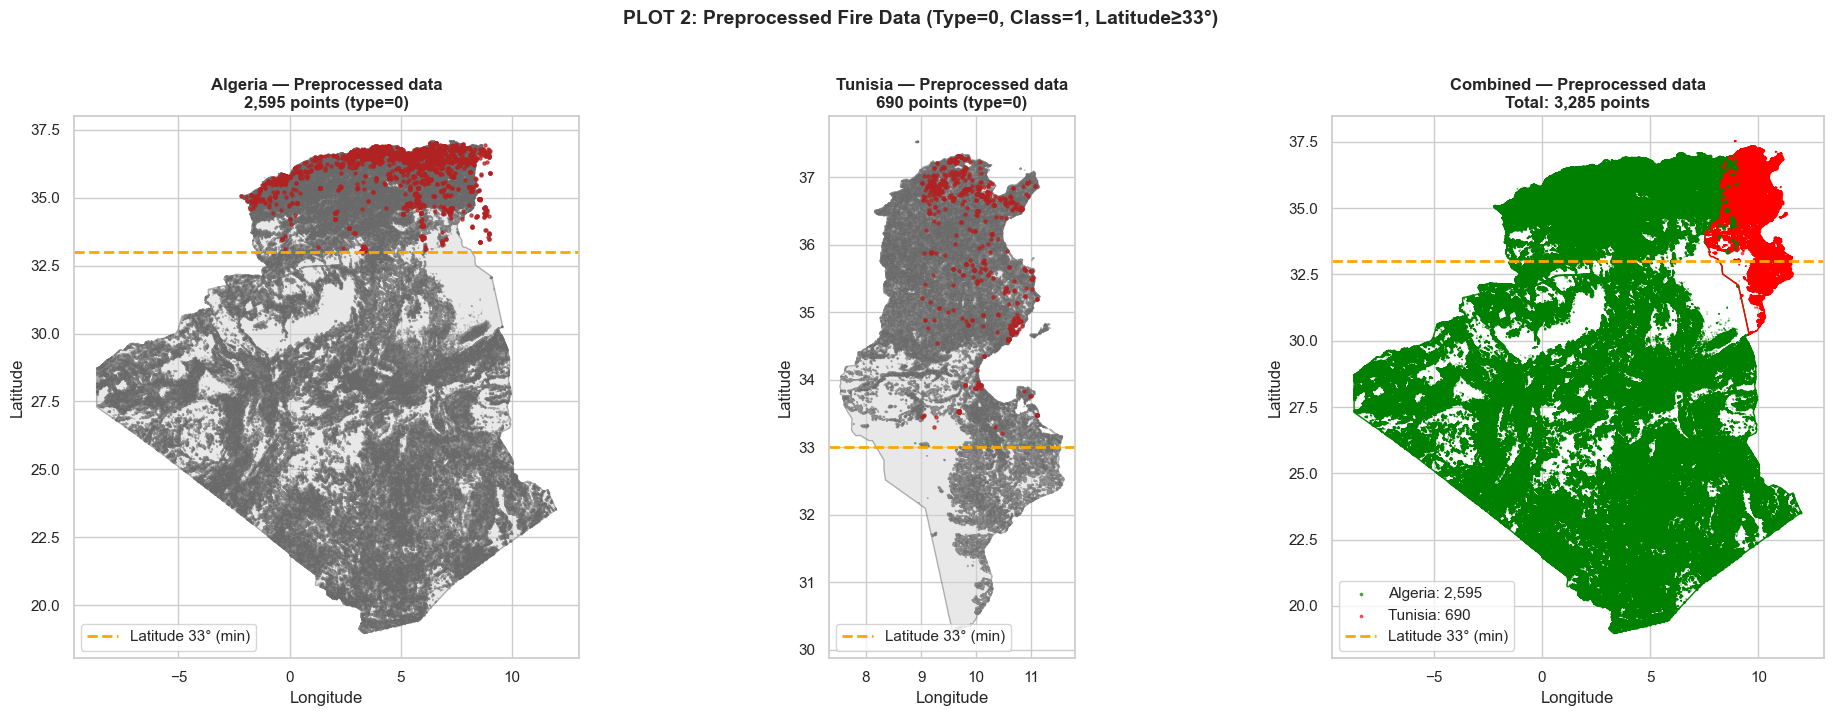


Filtering summary:
  Raw → Preprocessed: 90,250 → 3,285 (3.6% retained)
  Filters applied: type=0, latitude≥33, duplicates removed

✓ Preprocessed data loaded from: C:\Users\Azur\Downloads\TP\DM\results\data\fires_clipped.csv


In [10]:
# ============================================================================
# PLOT 2: AFTER PREPROCESSING (Type=0 only, class=1)
# ============================================================================
print("="*80)
print("PLOT 2: PREPROCESSED DATA (TYPE=0, CLASS=1)")
print("="*80)

# ============================================================================
# Load preprocessed data from FIRES_RESULT_CSV
# ============================================================================
print(f"\nLoading preprocessed data from {FIRES_RESULT_CSV.name}...")
preprocessed_df = pd.read_csv(FIRES_RESULT_CSV)

# Separate by country (using longitude as proxy: Algeria < 9, Tunisia >= 9)
algeria_preprocessed = preprocessed_df[preprocessed_df['longitude'] < 9].copy()
tunisia_preprocessed = preprocessed_df[preprocessed_df['longitude'] >= 9].copy()

print(f"Preprocessed data (type=0 only, class=1) from {FIRES_RESULT_CSV.name}:")
print(f"  Algeria: {len(algeria_preprocessed):,} fire points")
print(f"  Tunisia: {len(tunisia_preprocessed):,} fire points")
print(f"  Total: {len(preprocessed_df):,} fire points")

# Create geodataframes
alg_clean_gdf = gpd.GeoDataFrame(
    algeria_preprocessed,
    geometry=gpd.points_from_xy(algeria_preprocessed['longitude'], algeria_preprocessed['latitude']),
    crs='EPSG:4326'
)
tn_clean_gdf = gpd.GeoDataFrame(
    tunisia_preprocessed,
    geometry=gpd.points_from_xy(tunisia_preprocessed['longitude'], tunisia_preprocessed['latitude']),
    crs='EPSG:4326'
)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Left: Algeria
ax1 = axes[0]
algeria_lc.plot(ax=ax1, edgecolor='dimgray', facecolor='lightgray', alpha=0.5)
alg_clean_gdf.plot(ax=ax1, markersize=5, color='firebrick', alpha=0.7)
ax1.set_title(f'Algeria — Preprocessed data\n{len(algeria_preprocessed):,} points (type=0)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.axhline(y=33, color='orange', linestyle='--', linewidth=2, label='Latitude 33° (min)')
ax1.legend(loc='lower left')

# Middle: Tunisia
ax2 = axes[1]
tunisia_lc.plot(ax=ax2, edgecolor='dimgray', facecolor='lightgray', alpha=0.5)
tn_clean_gdf.plot(ax=ax2, markersize=5, color='firebrick', alpha=0.7)
ax2.set_title(f'Tunisia — Preprocessed data\n{len(tunisia_preprocessed):,} points (type=0)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.axhline(y=33, color='orange', linestyle='--', linewidth=2, label='Latitude 33° (min)')
ax2.legend(loc='lower left')

# Right: Combined view
ax3 = axes[2]
algeria_lc.plot(ax=ax3, edgecolor='green', facecolor='none', linewidth=1)
tunisia_lc.plot(ax=ax3, edgecolor='red', facecolor='none', linewidth=1)
alg_clean_gdf.plot(ax=ax3, markersize=3, color='green', alpha=0.6, label=f'Algeria: {len(algeria_preprocessed):,}')
tn_clean_gdf.plot(ax=ax3, markersize=3, color='red', alpha=0.6, label=f'Tunisia: {len(tunisia_preprocessed):,}')
ax3.set_title(f'Combined — Preprocessed data\nTotal: {len(preprocessed_df):,} points', fontsize=12, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.axhline(y=33, color='orange', linestyle='--', linewidth=2, label='Latitude 33° (min)')
ax3.legend(loc='lower left')

plt.suptitle('PLOT 2: Preprocessed Fire Data (Type=0, Class=1, Latitude≥33°)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print filtering summary
raw_total = len(pd.read_csv(FIRES_CSV))
print(f"\nFiltering summary:")
print(f"  Raw → Preprocessed: {raw_total:,} → {len(preprocessed_df):,} ({100*len(preprocessed_df)/raw_total:.1f}% retained)")
print(f"  Filters applied: type=0, latitude≥33, duplicates removed")
print(f"\n✓ Preprocessed data loaded from: {FIRES_RESULT_CSV}")

# 8 - Merging

In [ ]:
# =============================================================================
# 8. Generate Artificial Non-Fire Data (Class 0) - Grid-Based Approach
# =============================================================================
# FAST & SIMPLE: Grid-based sampling with latitude split (95/5)
# No land cover classification needed. ~3-5 seconds execution.

from shapely.geometry import Point, box
from shapely.ops import unary_union
from shapely.prepared import prep
import numpy as np

print("="*80)
print("GENERATING ARTIFICIAL NON-FIRE DATA (CLASS 0) - GRID-BASED APPROACH")
print("="*80)

# Check if output file already exists with valid data
if FIRES_WITH_ARTIFICIAL.exists():
    existing_df = pd.read_csv(FIRES_WITH_ARTIFICIAL)
    if len(existing_df) > 0 and 'class' in existing_df.columns:
        class_counts = existing_df['class'].value_counts()
        if 0 in class_counts.index and 1 in class_counts.index:
            pct_class0 = 100 * class_counts[0] / len(existing_df)
            expected_pct = 60
            if abs(pct_class0 - expected_pct) < 2:
                print(f"\n✓ SKIPPING: {FIRES_WITH_ARTIFICIAL.name} already exists with correct distribution")
                print(f"  Total rows: {len(existing_df):,}")
                print(f"  Class 0 (non-fire): {class_counts[0]:,} ({pct_class0:.1f}%)")
                print(f"  Class 1 (fire): {class_counts[1]:,} ({100*class_counts[1]/len(existing_df):.1f}%)")
                print(f"  To regenerate, delete the file first.")
                fires_with_artificial = existing_df
            else:
                print(f"\n⚠ Existing file has different distribution ({pct_class0:.1f}% vs {expected_pct}%)")
                print(f"  Regenerating...")
                existing_df = None
        else:
            existing_df = None
    else:
        existing_df = None
else:
    existing_df = None

if existing_df is None:
    # ============================================================================
    # STEP 1: Load class 1 (fire) data
    # ============================================================================
    fires_df = pd.read_csv(FIRES_RESULT_CSV)
    n_fire_points = len(fires_df)
    
    print(f"\n[STEP 1] Loaded class 1 (fire) data")
    print(f"  Shape: {fires_df.shape}")
    print(f"  Fire points: {n_fire_points:,}")
    
    # Create set of fire coordinates for duplicate checking
    fire_coords_set = set(zip(fires_df['longitude'].round(5), fires_df['latitude'].round(5)))
    print(f"  Unique fire coordinates: {len(fire_coords_set):,}")

    # ============================================================================
    # STEP 2: Load and prepare boundaries
    # ============================================================================
    print(f"\n[STEP 2] Loading country boundaries")
    print(f"  Algeria: {len(algeria_lc)} polygons")
    print(f"  Tunisia: {len(tunisia_lc)} polygons")
    
    if 'combined_boundary' not in dir() or combined_boundary is None:
        print("  Computing combined boundary...")
        algeria_boundary_geom = unary_union(algeria_lc.geometry)
        tunisia_boundary_geom = unary_union(tunisia_lc.geometry)
        combined_boundary = unary_union([algeria_boundary_geom, tunisia_boundary_geom])
        print(f"  ✓ Boundary computed: {combined_boundary.area:.2f} sq degrees")
    else:
        print(f"  Using cached boundary: {combined_boundary.area:.2f} sq degrees")
    
    prepared_boundary = prep(combined_boundary)
    minx, miny, maxx, maxy = combined_boundary.bounds
    print(f"  Bounds: lon=[{minx:.2f}, {maxx:.2f}], lat=[{miny:.2f}, {maxy:.2f}]")

    # ============================================================================
    # STEP 3: Create grid cells
    # ============================================================================
    print(f"\n[STEP 3] Creating grid cells")
    
    grid_resolution = 0.1  # degrees (roughly 11km x 8.5km)
    
    # Generate grid cells
    grid_cells = []
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            cell = {
                'x_min': x,
                'x_max': x + grid_resolution,
                'y_min': y,
                'y_max': y + grid_resolution,
                'lat': y + grid_resolution / 2,  # Center latitude for splitting
            }
            grid_cells.append(cell)
            y += grid_resolution
        x += grid_resolution
    
    print(f"  Total grid cells created: {len(grid_cells):,}")
    
    # Filter cells by latitude
    latitude_threshold = 33
    northern_cells = [c for c in grid_cells if c['lat'] > latitude_threshold]
    southern_cells = [c for c in grid_cells if c['lat'] <= latitude_threshold]
    
    print(f"  Northern cells (lat > {latitude_threshold}°): {len(northern_cells):,}")
    print(f"  Southern cells (lat ≤ {latitude_threshold}°): {len(southern_cells):,}")

    # ============================================================================
    # STEP 4: Calculate target points
    # ============================================================================
    print(f"\n[STEP 4] Calculating target points")
    
    multiplier = 1.5
    n_artificial_total = int(n_fire_points * multiplier)
    n_northern_target = int(n_artificial_total * 0.95)
    n_southern_target = n_artificial_total - n_northern_target
    
    total_final = n_fire_points + n_artificial_total
    pct_class0 = 100 * n_artificial_total / total_final
    pct_class1 = 100 * n_fire_points / total_final
    
    print(f"  Class 1 (fire): {n_fire_points:,}")
    print(f"  Class 0 (artificial) target: {n_artificial_total:,}")
    print(f"  Final distribution: {pct_class0:.1f}% class 0, {pct_class1:.1f}% class 1")
    print(f"  Geographic split of class 0:")
    print(f"    Northern (lat > {latitude_threshold}°): {n_northern_target:,} (95%)")
    print(f"    Southern (lat ≤ {latitude_threshold}°): {n_southern_target:,} (5%)")

    # ============================================================================
    # STEP 5: Generate points from northern grid
    # ============================================================================
    print(f"\n[STEP 5] Generating northern points...")
    
    northern_points = []
    np.random.seed(42)
    
    # Randomly sample cells (without replacement)
    sampled_northern_cells = np.random.choice(len(northern_cells), 
                                              min(len(northern_cells), n_northern_target // 2 + 1), 
                                              replace=False)
    
    for cell_idx in sampled_northern_cells:
        cell = northern_cells[cell_idx]
        
        # Generate multiple points per cell to reach target
        points_per_cell = max(1, n_northern_target // len(sampled_northern_cells))
        
        for _ in range(points_per_cell):
            if len(northern_points) >= n_northern_target:
                break
            
            # Random point with jitter within cell
            x = np.random.uniform(cell['x_min'], cell['x_max'])
            y = np.random.uniform(cell['y_min'], cell['y_max'])
            
            # Check if within boundary
            point = Point(x, y)
            if not prepared_boundary.contains(point):
                continue
            
            # Round for duplicate checking
            x_r, y_r = round(x, 5), round(y, 5)
            
            # Check duplicate with fire coordinates
            if (x_r, y_r) in fire_coords_set:
                continue
            
            # Check duplicate within artificial points
            if (x_r, y_r) not in [(p[0], p[1]) for p in northern_points]:
                northern_points.append((x_r, y_r))
        
        if len(northern_points) >= n_northern_target:
            break
    
    print(f"  Generated {len(northern_points):,} northern points")

    # ============================================================================
    # STEP 6: Generate points from southern grid
    # ============================================================================
    print(f"\n[STEP 6] Generating southern points...")
    
    southern_points = []
    
    # Randomly sample cells
    sampled_southern_cells = np.random.choice(len(southern_cells), 
                                              min(len(southern_cells), n_southern_target + 1), 
                                              replace=False)
    
    for cell_idx in sampled_southern_cells:
        cell = southern_cells[cell_idx]
        
        # More densely sample southern cells (fewer of them)
        points_per_cell = max(1, n_southern_target // max(1, len(sampled_southern_cells)))
        
        for _ in range(points_per_cell):
            if len(southern_points) >= n_southern_target:
                break
            
            x = np.random.uniform(cell['x_min'], cell['x_max'])
            y = np.random.uniform(cell['y_min'], cell['y_max'])
            
            point = Point(x, y)
            if not prepared_boundary.contains(point):
                continue
            
            x_r, y_r = round(x, 5), round(y, 5)
            
            if (x_r, y_r) in fire_coords_set:
                continue
            
            if (x_r, y_r) not in [(p[0], p[1]) for p in southern_points]:
                southern_points.append((x_r, y_r))
        
        if len(southern_points) >= n_southern_target:
            break
    
    print(f"  Generated {len(southern_points):,} southern points")

    # ============================================================================
    # STEP 7: Merge north + south and check duplicates
    # ============================================================================
    print(f"\n[STEP 7] Merging and checking duplicates")
    
    all_artificial_points = northern_points + southern_points
    print(f"  Total artificial points before duplicate check: {len(all_artificial_points):,}")
    
    # Check duplicates with fire data
    duplicates_removed = 0
    for pt in list(all_artificial_points):
        if pt in fire_coords_set:
            all_artificial_points.remove(pt)
            duplicates_removed += 1
    
    print(f"  Duplicates removed: {duplicates_removed}")
    print(f"  Artificial points after deduplication: {len(all_artificial_points):,}")

    # ============================================================================
    # STEP 8: Ensure 60/40 ratio
    # ============================================================================
    print(f"\n[STEP 8] Adjusting to ensure 60/40 ratio")
    
    current_class0 = len(all_artificial_points)
    current_class1 = n_fire_points
    current_total = current_class0 + current_class1
    current_pct_c0 = 100 * current_class0 / current_total
    
    print(f"  Current class 0: {current_class0:,}")
    print(f"  Current class 1: {current_class1:,}")
    print(f"  Current distribution: {current_pct_c0:.1f}% class 0")
    
    # If we're short on class 0, try to generate more from remaining cells
    target_class0 = int(current_total * 0.60)
    if current_class0 < target_class0:
        shortage = target_class0 - current_class0
        print(f"  Shortage: {shortage:,} points. Attempting to generate...")
        
        # Generate more points
        additional_points = []
        remaining_cells = [c for c in grid_cells if c not in sampled_northern_cells and c not in sampled_southern_cells]
        
        for cell in remaining_cells:
            if len(additional_points) >= shortage:
                break
            
            for _ in range(2):  # Try multiple times per cell
                if len(additional_points) >= shortage:
                    break
                
                x = np.random.uniform(cell['x_min'], cell['x_max'])
                y = np.random.uniform(cell['y_min'], cell['y_max'])
                
                point = Point(x, y)
                if not prepared_boundary.contains(point):
                    continue
                
                x_r, y_r = round(x, 5), round(y, 5)
                
                # Crucial: never remove fire points, skip duplicates with fires
                if (x_r, y_r) in fire_coords_set:
                    continue
                
                if (x_r, y_r) not in [(p[0], p[1]) for p in all_artificial_points + additional_points]:
                    additional_points.append((x_r, y_r))
        
        all_artificial_points.extend(additional_points)
        print(f"  Generated {len(additional_points):,} additional points")
        print(f"  Final class 0: {len(all_artificial_points):,}")
    
    final_class0 = len(all_artificial_points)
    final_pct_c0 = 100 * final_class0 / (final_class0 + current_class1)
    print(f"  Final distribution: {final_pct_c0:.1f}% class 0, {100-final_pct_c0:.1f}% class 1")

    # ============================================================================
    # STEP 9: Create DataFrames and combine
    # ============================================================================
    print(f"\n[STEP 9] Creating final dataset")
    
    artificial_df = pd.DataFrame(all_artificial_points, columns=['longitude', 'latitude'])
    artificial_df['class'] = 0
    
    fires_df_clean = fires_df[['longitude', 'latitude', 'class']].copy()
    fires_with_artificial = pd.concat([fires_df_clean, artificial_df], ignore_index=True)
    
    # Shuffle and save
    fires_with_artificial = fires_with_artificial.sample(frac=1, random_state=42).reset_index(drop=True)
    fires_with_artificial.to_csv(FIRES_WITH_ARTIFICIAL, index=False)
    print(f"  Saved to: {FIRES_WITH_ARTIFICIAL}")

    # ============================================================================
    # SUMMARY AND VERIFICATION
    # ============================================================================
    print("\n" + "="*80)
    print("SUMMARY - ARTIFICIAL DATA GENERATION")
    print("="*80)
    
    print(f"\nFinal dataset shape: {fires_with_artificial.shape}")
    
    class_counts = fires_with_artificial['class'].value_counts().sort_index()
    
    print(f"\n✓ REQUIREMENT 1 - CLASS DISTRIBUTION (60/40):")
    for cls in [0, 1]:
        if cls in class_counts.index:
            count = class_counts[cls]
            pct = 100 * count / len(fires_with_artificial)
            target = 60 if cls == 0 else 40
            status = "✓" if abs(pct - target) <= 2 else "⚠"
            class_name = "non-fire (artificial)" if cls == 0 else "fire (real)"
            print(f"  {status} Class {cls} ({class_name:20s}): {count:>5,} ({pct:>5.1f}% - target {target}%)")
    
    # Check geographic split in class 0
    class0_df = fires_with_artificial[fires_with_artificial['class'] == 0]
    northern_c0 = len(class0_df[class0_df['latitude'] > latitude_threshold])
    southern_c0 = len(class0_df[class0_df['latitude'] <= latitude_threshold])
    if len(class0_df) > 0:
        north_pct = 100 * northern_c0 / len(class0_df)
        south_pct = 100 * southern_c0 / len(class0_df)
    else:
        north_pct = south_pct = 0
    
    print(f"\n✓ REQUIREMENT 2 - GEOGRAPHIC SPLIT (within class 0, 95/5):")
    status_n = "✓" if abs(north_pct - 95) <= 2 else "⚠"
    status_s = "✓" if abs(south_pct - 5) <= 2 else "⚠"
    print(f"  {status_n} Northern (lat > {latitude_threshold}°): {northern_c0:>5,} ({north_pct:>5.1f}% - target 95%)")
    print(f"  {status_s} Southern (lat ≤ {latitude_threshold}°): {southern_c0:>5,} ({south_pct:>5.1f}% - target 5%)")
    
    # Check for duplicates
    unique_coords = len(fires_with_artificial.drop_duplicates(subset=['longitude', 'latitude']))
    total_rows = len(fires_with_artificial)
    duplicates_found = total_rows - unique_coords
    
    print(f"\n✓ REQUIREMENT 3 - NO DUPLICATES:")
    status_dup = "✓" if duplicates_found == 0 else "⚠"
    print(f"  {status_dup} Total rows: {total_rows:,}")
    print(f"  {status_dup} Unique positions: {unique_coords:,}")
    print(f"  {status_dup} Duplicates found: {duplicates_found}")
    
    print(f"\nData ranges:")
    print(f"  Longitude: [{fires_with_artificial['longitude'].min():.4f}, {fires_with_artificial['longitude'].max():.4f}]")
    print(f"  Latitude: [{fires_with_artificial['latitude'].min():.4f}, {fires_with_artificial['latitude'].max():.4f}]")
    
    print(f"\n✓ Dataset saved to: {FIRES_WITH_ARTIFICIAL}")
    print("="*80)
    
    display(fires_with_artificial.head(10))

GENERATING ARTIFICIAL NON-FIRE DATA (CLASS 0)
Vegetation-Weighted Sampling within Algeria/Tunisia Boundaries

[STEP 1] Loaded preprocessed fire data from: C:\Users\Azur\Downloads\TP\DM\results\data\fires_clipped.csv
  Shape: (3285, 3)
  Columns: ['longitude', 'latitude', 'class']

Class distribution BEFORE adding artificial data:
class
1    3285
Name: count, dtype: int64

[STEP 2] Loading land cover data and country boundaries...
  Using cached land cover data: 438513 polygons
  Using Algeria landcover as boundary: 386454 polygons
  Using Tunisia landcover as boundary: 52059 polygons
  Using cached combined boundary: 228.61 sq degrees

[STEP 3] Categorizing land cover polygons...
  Using class column: landcover


  Vegetation polygons: 0
  Desert/Bare polygons: 438513

[STEP 4] Generating artificial non-fire points...

  Artificial points to generate: 4927
  Target distribution: 60% class 0, 40% class 1
    Northern (lat > 33): 4680 (95%)
      - Vegetation: 3978
      - Desert: 702
    Saharan (lat <= 33): 247 (5%)
      - Vegetation (oases): 209
      - Desert: 38

  Generating NORTHERN points (lat > 33)...
    No northern vegetation polygons available or 0 points requested!
    Generated 702 northern desert points

  Generating SAHARAN points (lat <= 33)...
    No saharan vegetation (oases) polygons available or 0 points requested!
    Generated 38 saharan desert points

  Total artificial points generated: 740
    Northern: 702
    Saharan: 38

[STEP 5] Creating artificial data DataFrame...
  Artificial data shape: (740, 3)

[STEP 6] Combining real fire data with artificial non-fire data...
  Real fire data (class 1): 3285 rows
  Artificial data (class 0): 740 rows

[STEP 7] Shuffling the c

,longitude,latitude,class
0,5.487640,36.334900,1
1,5.519330,36.125370,1
2,9.734510,36.604290,1
3,0.327430,34.798270,1
4,6.124320,36.600110,1
5,3.881500,35.725480,1
6,5.015634,36.385646,0
7,7.077940,34.573230,1
8,6.355780,36.125930,1
9,3.734419,26.649110,0


PLOT 3: FINAL DATASET (CLASS 0 + CLASS 1)
Final dataset with artificial non-fire points:
  Fire points (class=1): 3,285
  Non-fire points (class=0): 493
  Total: 3,778


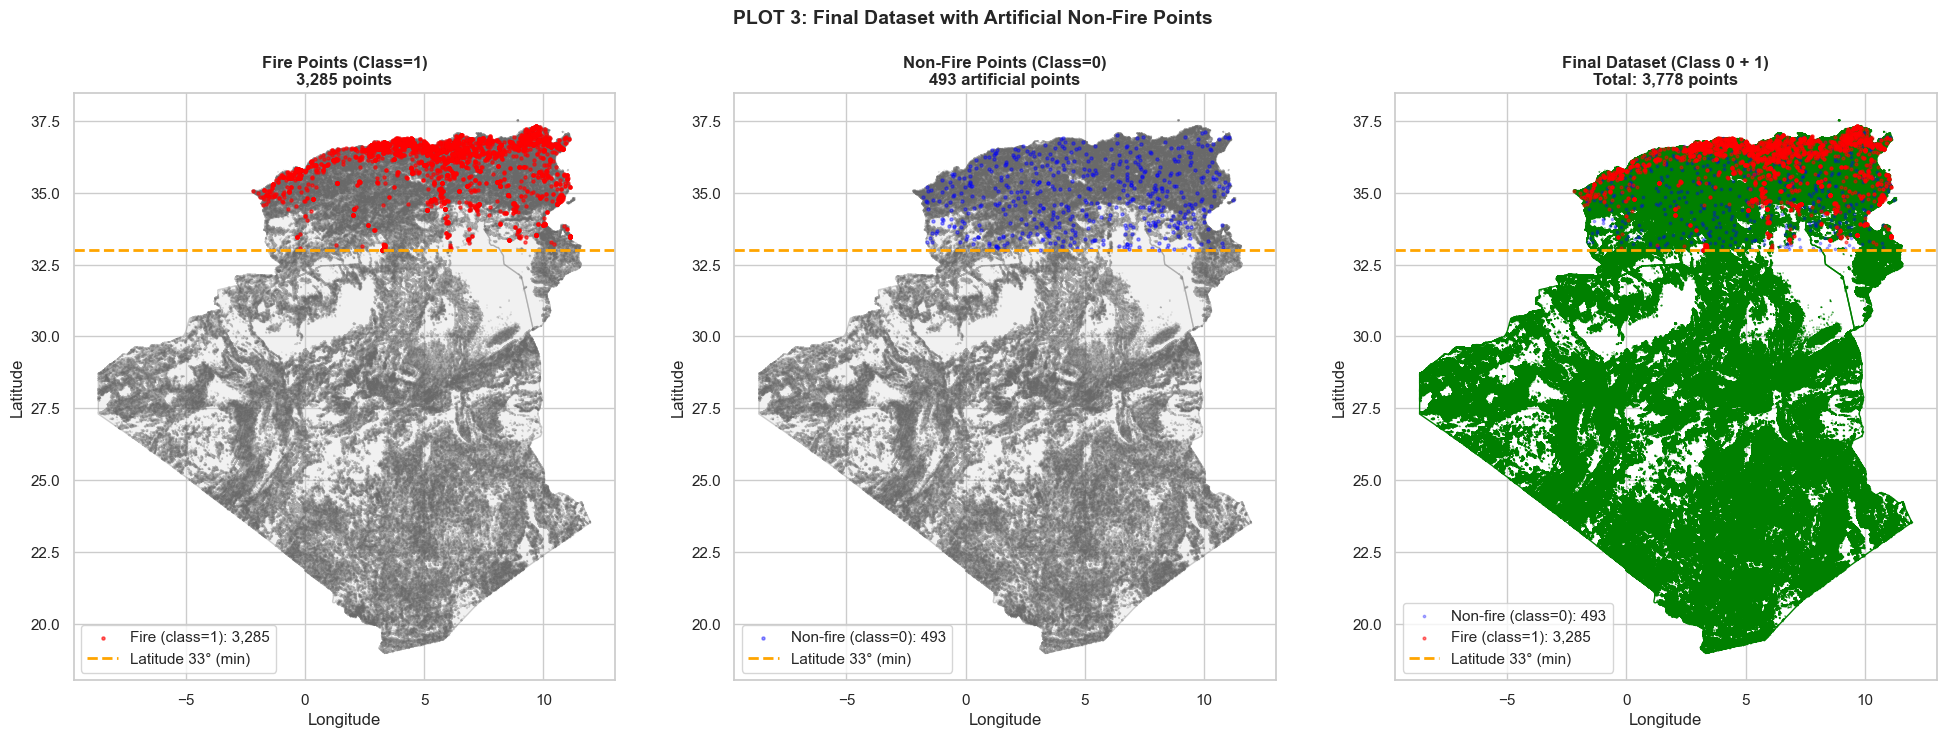


Class distribution:
  Class 0 (non-fire): 493 (13.0%)
  Class 1 (fire):     3,285 (87.0%)

Verification:
  All points above latitude 33°: True
  Longitude range: [-2.18, 11.21]
  Latitude range: [33.01, 37.32]

✓ Saved to: C:\Users\Azur\Downloads\TP\DM\results\intermediate\fires_with_artificial_clipped.csv


In [29]:
# ============================================================================
# PLOT 3: AFTER ARTIFICIAL DATA GENERATION (Class 0 and 1)
# ============================================================================
print("="*80)
print("PLOT 3: FINAL DATASET (CLASS 0 + CLASS 1)")
print("="*80)

# Load the saved dataset with artificial points
loaded_df = pd.read_csv(FIRES_WITH_ARTIFICIAL)
loaded_df = loaded_df.round(5)

# Separate by class
fire_points = loaded_df[loaded_df['class'] == 1]
nonfire_points = loaded_df[loaded_df['class'] == 0]

print(f"Final dataset with artificial non-fire points:")
print(f"  Fire points (class=1): {len(fire_points):,}")
print(f"  Non-fire points (class=0): {len(nonfire_points):,}")
print(f"  Total: {len(loaded_df):,}")

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Left: Fire points only (class=1)
ax1 = axes[0]
algeria_lc.plot(ax=ax1, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
tunisia_lc.plot(ax=ax1, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
ax1.scatter(fire_points['longitude'], fire_points['latitude'], 
            c='red', s=5, alpha=0.6, label=f'Fire (class=1): {len(fire_points):,}')
ax1.set_title(f'Fire Points (Class=1)\n{len(fire_points):,} points', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.axhline(y=33, color='orange', linestyle='--', linewidth=2, label='Latitude 33° (min)')
ax1.legend(loc='lower left')

# Middle: Non-fire points only (class=0)
ax2 = axes[1]
algeria_lc.plot(ax=ax2, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
tunisia_lc.plot(ax=ax2, edgecolor='dimgray', facecolor='lightgray', alpha=0.3)
ax2.scatter(nonfire_points['longitude'], nonfire_points['latitude'], 
            c='blue', s=5, alpha=0.4, label=f'Non-fire (class=0): {len(nonfire_points):,}')
ax2.set_title(f'Non-Fire Points (Class=0)\n{len(nonfire_points):,} artificial points', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.axhline(y=33, color='orange', linestyle='--', linewidth=2, label='Latitude 33° (min)')
ax2.legend(loc='lower left')

# Right: Combined view (both classes)
ax3 = axes[2]
algeria_lc.plot(ax=ax3, edgecolor='green', facecolor='none', linewidth=1)
tunisia_lc.plot(ax=ax3, edgecolor='green', facecolor='none', linewidth=1)
ax3.scatter(nonfire_points['longitude'], nonfire_points['latitude'], 
            c='blue', s=3, alpha=0.3, label=f'Non-fire (class=0): {len(nonfire_points):,}')
ax3.scatter(fire_points['longitude'], fire_points['latitude'], 
            c='red', s=4, alpha=0.5, label=f'Fire (class=1): {len(fire_points):,}')
ax3.set_title(f'Final Dataset (Class 0 + 1)\nTotal: {len(loaded_df):,} points', fontsize=12, fontweight='bold')
ax3.set_xlabel('Longitude')
ax3.set_ylabel('Latitude')
ax3.axhline(y=33, color='orange', linestyle='--', linewidth=2, label='Latitude 33° (min)')
ax3.legend(loc='lower left')

plt.suptitle('PLOT 3: Final Dataset with Artificial Non-Fire Points', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print class balance
print(f"\nClass distribution:")
print(f"  Class 0 (non-fire): {len(nonfire_points):,} ({100*len(nonfire_points)/len(loaded_df):.1f}%)")
print(f"  Class 1 (fire):     {len(fire_points):,} ({100*len(fire_points)/len(loaded_df):.1f}%)")

# Verification stats
print(f"\nVerification:")
print(f"  All points above latitude 33°: {(loaded_df['latitude'] >= 33).all()}")
print(f"  Longitude range: [{loaded_df['longitude'].min():.2f}, {loaded_df['longitude'].max():.2f}]")
print(f"  Latitude range: [{loaded_df['latitude'].min():.2f}, {loaded_df['latitude'].max():.2f}]")

# Save final version
loaded_df.to_csv(FIRES_WITH_ARTIFICIAL, index=False)
print(f"\n✓ Saved to: {FIRES_WITH_ARTIFICIAL}")

⚠️ **WARNING**: Run the following cells **only after** executing:
- `soil.ipynb`
- `elevation.ipynb`
- `climate.ipynb`

These notebooks must be completed first to generate the required feature datasets.

In [30]:
print("="*80)
print("REMOVING SEA POINTS FROM ALL DATASETS")
print("="*80)

# ============================================================================
# STEP 1: Load fires_with_soil_features.csv
# ============================================================================
print("\n[STEP 1] Loading fires_with_soil_features.csv...")
soil_df = pd.read_csv(FIRES_WITH_SOIL)

print(f"Loaded soil features dataset:")
print(f"  Shape: {soil_df.shape}")
print(f"  Columns: {list(soil_df.columns)}")

# ============================================================================
# STEP 2: Identify sea points (class=0 with empty soil features)
# ============================================================================
print("\n[STEP 2] Identifying sea points...")

# Identify soil feature columns (excluding longitude, latitude, class)
soil_feature_cols = [col for col in soil_df.columns 
                     if col not in ['longitude', 'latitude', 'class']]

print(f"Soil feature columns: {soil_feature_cols}")

# Find rows where class=0 AND all soil features are empty (,,,,)
sea_mask = (soil_df['class'] == 0) & (soil_df[soil_feature_cols].isna().all(axis=1))
sea_points = soil_df[sea_mask][['longitude', 'latitude']].copy()

print(f"\nSea points identified: {len(sea_points)} rows")
print(f"  (class=0 with all soil features empty)")

# ============================================================================
# STEP 3: Save sea points to sea.csv
# ============================================================================
print("\n[STEP 3] Saving sea points to sea.csv...")
sea_points.to_csv(SEA_CSV, index=False)
print(f"  Sea points saved to: {SEA_CSV}")

print("\nSample of sea points (first 5):")
display(sea_points.head())

# ============================================================================
# STEP 4: Remove sea points from fires_with_soil_features.csv
# ============================================================================
print("\n[STEP 4] Removing sea points from fires_with_soil_features.csv...")
print(f"  Before: {len(soil_df)} rows")

soil_df_clean = soil_df[~sea_mask].copy()

print(f"  After: {len(soil_df_clean)} rows")
print(f"  Removed: {len(soil_df) - len(soil_df_clean)} sea points")

# Save cleaned soil features
soil_df_clean.to_csv(FIRES_WITH_SOIL, index=False)
print(f"  Updated fires_with_soil_features.csv saved")

# ============================================================================
# STEP 5: Load and clean fires.csv
# ============================================================================
print("\n[STEP 5] Loading and cleaning fires.csv...")
fires_df = pd.read_csv(FIRES_RESULT_CSV)

print(f"  Before: {len(fires_df)} rows")

# Merge to find matching sea points
fires_merged = fires_df.merge(
    sea_points.assign(is_sea=True),
    on=['longitude', 'latitude'],
    how='left'
)
fires_df_clean = fires_merged[fires_merged['is_sea'].isna()][fires_df.columns].copy()

print(f"  After: {len(fires_df_clean)} rows")
print(f"  Removed: {len(fires_df) - len(fires_df_clean)} sea points")

fires_df_clean.to_csv(FIRES_RESULT_CSV, index=False)
print(f"  Updated fires.csv saved")

# ============================================================================
# STEP 6: Load and clean fires_with_climate.csv
# ============================================================================
print("\n[STEP 6] Loading and cleaning fires_with_climate.csv...")
climate_df = pd.read_csv(FIRES_WITH_CLIMATE)

print(f"  Before: {len(climate_df)} rows")

# Merge to find matching sea points
climate_merged = climate_df.merge(
    sea_points.assign(is_sea=True),
    on=['longitude', 'latitude'],
    how='left'
)
climate_df_clean = climate_merged[climate_merged['is_sea'].isna()][climate_df.columns].copy()

print(f"  After: {len(climate_df_clean)} rows")
print(f"  Removed: {len(climate_df) - len(climate_df_clean)} sea points")

climate_df_clean.to_csv(FIRES_WITH_CLIMATE, index=False)
print(f"  Updated fires_with_climate.csv saved")

# ============================================================================
# STEP 7: Load and clean fires_with_elevation_features.csv
# ============================================================================
print("\n[STEP 7] Loading and cleaning fires_with_elevation_features.csv...")
elevation_df = pd.read_csv(FIRES_WITH_ELEVATION)

print(f"  Before: {len(elevation_df)} rows")

# Merge to find matching sea points
elevation_merged = elevation_df.merge(
    sea_points.assign(is_sea=True),
    on=['longitude', 'latitude'],
    how='left'
)
elevation_df_clean = elevation_merged[elevation_merged['is_sea'].isna()][elevation_df.columns].copy()

print(f"  After: {len(elevation_df_clean)} rows")
print(f"  Removed: {len(elevation_df) - len(elevation_df_clean)} sea points")

elevation_df_clean.to_csv(FIRES_WITH_ELEVATION, index=False)
print(f"  Updated fires_with_elevation_features.csv saved")

# ============================================================================
# STEP 8: Load and clean fires_with_artificial.csv using soil as reference
# ============================================================================
print("\n[STEP 8] Loading and cleaning fires_with_artificial.csv...")
artificial_df = pd.read_csv(FIRES_WITH_ARTIFICIAL)

print(f"  Before: {len(artificial_df)} rows")

# Use cleaned soil dataset as reference (contains only land points)
soil_coords = soil_df_clean[['longitude', 'latitude']].copy()
soil_coords['in_soil'] = True

# Keep only coordinates that exist in cleaned soil dataset
artificial_merged = artificial_df.merge(
    soil_coords,
    on=['longitude', 'latitude'],
    how='inner'
)
artificial_df_clean = artificial_merged[artificial_df.columns].copy()

print(f"  After: {len(artificial_df_clean)} rows")
print(f"  Removed: {len(artificial_df) - len(artificial_df_clean)} points not in soil dataset")

artificial_df_clean.to_csv(FIRES_WITH_ARTIFICIAL, index=False)
print(f"  Updated fires_with_artificial.csv saved")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SEA POINTS REMOVAL COMPLETE - SUMMARY")
print("="*80)
print(f"\nSea points identified and saved:")
print(f"  File: {SEA_CSV}")
print(f"  Count: {len(sea_points):,} points")

print(f"\nDatasets cleaned (sea points removed):")
print(f"  fires.csv:                        {len(fires_df):,} → {len(fires_df_clean):,} rows")
print(f"  fires_with_climate.csv:           {len(climate_df):,} → {len(climate_df_clean):,} rows")
print(f"  fires_with_elevation_features.csv: {len(elevation_df):,} → {len(elevation_df_clean):,} rows")
print(f"  fires_with_soil_features.csv:     {len(soil_df):,} → {len(soil_df_clean):,} rows")
print(f"  fires_with_artificial.csv:        {len(artificial_df):,} → {len(artificial_df_clean):,} rows")

print(f"\nAll datasets now contain only land points!")
print("="*80)

# Display previews
print("\nPreview of cleaned fires.csv (first 5):")
display(fires_df_clean.head())

print("\nClass distribution in cleaned datasets:")
print("\nfires.csv:")
print(fires_df_clean['class'].value_counts().sort_index())

print("\nfires_with_climate.csv:")
print(climate_df_clean['class'].value_counts().sort_index())

print("\nfires_with_elevation_features.csv:")
print(elevation_df_clean['class'].value_counts().sort_index())

print("\nfires_with_soil_features.csv:")
print(soil_df_clean['class'].value_counts().sort_index())

print("\nfires_with_artificial.csv:")
print(artificial_df_clean['class'].value_counts().sort_index())

REMOVING SEA POINTS FROM ALL DATASETS

[STEP 1] Loading fires_with_soil_features.csv...


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Azur\\Downloads\\TP\\DM\\results\\intermediate\\fires_with_soil_features.csv'

In [ ]:
# load fires.csv
fires_df = pd.read_csv(FIRES_RESULT_CSV)

# check if there are rows with similar position (lat,log) (same up to 5 decimal places)
fires_df['longitude'] = fires_df['longitude'].round(5)
fires_df['latitude'] = fires_df['latitude'].round(5)
duplicates = fires_df.duplicated(subset=['longitude', 'latitude'], keep=False)
duplicate_rows = fires_df[duplicates]
print(f"Number of rows with duplicate positions (lat, lon): {len(duplicate_rows)}")

Number of rows with duplicate positions (lat, lon): 0


In [ ]:
# Load all datasets
print("="*80)
print("SYNCHRONIZING DATASETS WITH fires.csv")
print("="*80)

# Load fires.csv (reference dataset)
fires_ref = pd.read_csv(FIRES_RESULT_CSV)
print(f"\n[1] Loaded fires.csv: {fires_ref.shape}")

# Load other datasets
soil_sync = pd.read_csv(FIRES_WITH_SOIL)
print(f"[2] Loaded fires_with_soil_features.csv: {soil_sync.shape}")

elevation_sync = pd.read_csv(FIRES_WITH_ELEVATION)
print(f"[3] Loaded fires_with_elevation_features.csv: {elevation_sync.shape}")

climate_sync = pd.read_csv(FIRES_WITH_CLIMATE)
print(f"[4] Loaded fires_with_climate.csv: {climate_sync.shape}")

# Create reference set of (longitude, latitude) pairs from fires.csv
fires_coords = fires_ref[['longitude', 'latitude']].copy()
fires_coords['in_fires'] = True

print(f"\nReference coordinates from fires.csv: {len(fires_coords)} unique pairs")

# Filter soil dataset
soil_filtered = soil_sync.merge(fires_coords, on=['longitude', 'latitude'], how='inner')
soil_filtered = soil_filtered.drop(columns=['in_fires'])
print(f"\n[SOIL] Before: {len(soil_sync)} rows → After: {len(soil_filtered)} rows")

# Filter elevation dataset
elevation_filtered = elevation_sync.merge(fires_coords, on=['longitude', 'latitude'], how='inner')
elevation_filtered = elevation_filtered.drop(columns=['in_fires'])
print(f"[ELEVATION] Before: {len(elevation_sync)} rows → After: {len(elevation_filtered)} rows")

# Filter climate dataset
climate_filtered = climate_sync.merge(fires_coords, on=['longitude', 'latitude'], how='inner')
climate_filtered = climate_filtered.drop(columns=['in_fires'])
print(f"[CLIMATE] Before: {len(climate_sync)} rows → After: {len(climate_filtered)} rows")

# Save filtered datasets
soil_filtered.to_csv(FIRES_WITH_SOIL, index=False)
print(f"\n✓ Updated {FIRES_WITH_SOIL}")

elevation_filtered.to_csv(FIRES_WITH_ELEVATION, index=False)
print(f"✓ Updated {FIRES_WITH_ELEVATION}")

climate_filtered.to_csv(FIRES_WITH_CLIMATE, index=False)
print(f"✓ Updated {FIRES_WITH_CLIMATE}")

print("\n" + "="*80)
print("SYNCHRONIZATION COMPLETE")
print("="*80)
print(f"All datasets now contain exactly {len(fires_ref)} rows matching fires.csv")

# Verify class distribution consistency
print("\nClass distribution verification:")
print(f"fires.csv:              {fires_ref['class'].value_counts().sort_index().to_dict()}")
print(f"soil_features.csv:      {soil_filtered['class'].value_counts().sort_index().to_dict()}")
print(f"elevation_features.csv: {elevation_filtered['class'].value_counts().sort_index().to_dict()}")
print(f"climate.csv:            {climate_filtered['class'].value_counts().sort_index().to_dict()}")
print("="*80)

SYNCHRONIZING DATASETS WITH fires.csv

[1] Loaded fires.csv: (7302, 3)
[2] Loaded fires_with_soil_features.csv: (7302, 28)
[3] Loaded fires_with_elevation_features.csv: (7302, 7)
[4] Loaded fires_with_climate.csv: (7302, 15)

Reference coordinates from fires.csv: 7302 unique pairs

[SOIL] Before: 7302 rows → After: 7302 rows
[ELEVATION] Before: 7302 rows → After: 7302 rows
[CLIMATE] Before: 7302 rows → After: 7302 rows

✓ Updated C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_soil_features.csv
✓ Updated C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_elevation_features.csv
✓ Updated C:\Users\mehdi\OneDrive\Bureau\DM\Project\results\intermediate\fires_with_climate.csv

SYNCHRONIZATION COMPLETE
All datasets now contain exactly 7302 rows matching fires.csv

Class distribution verification:
fires.csv:              {0: 4017, 1: 3285}
soil_features.csv:      {0: 4017, 1: 3285}
elevation_features.csv: {0: 4017, 1: 3285}
climate.csv:        